# Web Voyager

- https://langchain-ai.github.io/langgraph/tutorials/web-navigation/web_voyager/

- https://www.youtube.com/watch?v=ylrew7qb8sQ

- https://www.youtube.com/watch?v=7kbQnLN2y_I

In [1]:
!pip install langchain-openai>~0.2.9
!pip install -U --quiet langgraph langchain_openai


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import nest_asyncio
import dotenv

dotenv.load_dotenv()

nest_asyncio.apply()

In [3]:
from typing import List, Optional
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage, SystemMessage
from playwright.async_api import Page


class BBox(TypedDict):
    x: float
    y: float
    text: str
    type: str
    ariaLabel: str


class Prediction(TypedDict):
    action: str
    args: Optional[List[str]]


# This represents the state of the agent
# as it proceeds through execution
class AgentState(TypedDict):
    page: Page  # The Playwright web page lets us interact with the web environment
    input: str  # User request
    img: str  # b64 encoded screenshot
    bboxes: List[BBox]  # The bounding boxes from the browser annotation function
    prediction: Prediction  # The Agent's output
    # A system message (or messages) containing the intermediate steps
    scratchpad: List[BaseMessage]
    observation: str  # The most recent response from a tool

In [4]:
import asyncio
import platform


async def click(state: AgentState):
    # - Click [Numerical_Label]
    page = state["page"]
    click_args = state["prediction"]["args"]
    if click_args is None or len(click_args) != 1:
        return f"Failed to click bounding box labeled as number {click_args}"
    bbox_id = click_args[0]
    bbox_id = int(bbox_id)
    try:
        bbox = state["bboxes"][bbox_id]
    except Exception:
        return f"Error: no bbox for : {bbox_id}"
    x, y = bbox["x"], bbox["y"]
    await page.mouse.click(x, y)
    # TODO: In the paper, they automatically parse any downloaded PDFs
    # We could add something similar here as well and generally
    # improve response format.
    return f"Clicked {bbox_id}"


async def type_text(state: AgentState):
    page = state["page"]
    type_args = state["prediction"]["args"]
    if type_args is None or len(type_args) != 2:
        return (
            f"Failed to type in element from bounding box labeled as number {type_args}"
        )
    bbox_id = type_args[0]
    bbox_id = int(bbox_id)
    bbox = state["bboxes"][bbox_id]
    x, y = bbox["x"], bbox["y"]
    text_content = type_args[1]
    await page.mouse.click(x, y)
    # Check if MacOS
    select_all = "Meta+A" if platform.system() == "Darwin" else "Control+A"
    await page.keyboard.press(select_all)
    await page.keyboard.press("Backspace")
    await page.keyboard.type(text_content)
    await page.keyboard.press("Enter")
    return f"Typed {text_content} and submitted"


async def scroll(state: AgentState):
    page = state["page"]
    scroll_args = state["prediction"]["args"]
    if scroll_args is None or len(scroll_args) != 2:
        return "Failed to scroll due to incorrect arguments."

    target, direction = scroll_args

    if target.upper() == "WINDOW":
        # Not sure the best value for this:
        scroll_amount = 500
        scroll_direction = (
            -scroll_amount if direction.lower() == "up" else scroll_amount
        )
        await page.evaluate(f"window.scrollBy(0, {scroll_direction})")
    else:
        # Scrolling within a specific element
        scroll_amount = 200
        target_id = int(target)
        bbox = state["bboxes"][target_id]
        x, y = bbox["x"], bbox["y"]
        scroll_direction = (
            -scroll_amount if direction.lower() == "up" else scroll_amount
        )
        await page.mouse.move(x, y)
        await page.mouse.wheel(0, scroll_direction)

    return f"Scrolled {direction} in {'window' if target.upper() == 'WINDOW' else 'element'}"


async def wait(state: AgentState):
    sleep_time = 5
    await asyncio.sleep(sleep_time)
    return f"Waited for {sleep_time}s."


async def go_back(state: AgentState):
    page = state["page"]
    await page.go_back()
    return f"Navigated back a page to {page.url}."


async def to_google(state: AgentState):
    page = state["page"]
    await page.goto("https://duckduckgo.com/")
    return "Navigated to google.com."

In [21]:
import base64

from langchain_core.runnables import chain as chain_decorator

# Some javascript we will run on each step
# to take a screenshot of the page, select the
# elements to annotate, and add bounding boxes
with open("mark_page_backup_full_page.js") as f:
    mark_page_script = f.read()


@chain_decorator
async def mark_page(page):
    await page.evaluate(mark_page_script)
    for _ in range(10):
        try:
            bboxes = await page.evaluate("markPage()")
            break
        except Exception:
            # May be loading...
            await asyncio.sleep(3)
    screenshot = await page.screenshot()
    # Ensure the bboxes don't follow us around
    await page.evaluate("unmarkPage()")
    return {
        "img": base64.b64encode(screenshot).decode(),
        "bboxes": bboxes,
    }

In [22]:
from langchain import hub
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_openai import ChatOpenAI


async def annotate(state):
    print("annotate")
    marked_page = await mark_page.with_retry().ainvoke(state["page"])
    return {**state, **marked_page}


def format_descriptions(state):
    """
    Formata as descrições dos bounding boxes de elementos web para uso em automação.
    
    Esta função processa uma lista de bounding boxes de elementos web e cria
    descrições textuais padronizadas, priorizando ariaLabel quando disponível
    e usando o texto do elemento como fallback.
    
    Args:
        state (dict): Estado contendo informações dos elementos web com a chave:
            - bboxes (list): Lista de dicionários, cada um representando um elemento web
              com as seguintes chaves opcionais:
                - ariaLabel (str, opcional): Label de acessibilidade do elemento
                - text (str): Texto visível do elemento
                - type (str, opcional): Tipo do elemento HTML (ex: 'button', 'input')
    
    Returns:
        dict: Estado original atualizado com nova chave:
            - bbox_descriptions (str): String formatada contendo todas as descrições
              dos elementos no formato: 'índice (<tipo/>): "texto"'
    
    Example:
        >>> state = {
        ...     "bboxes": [
        ...         {"ariaLabel": "Search button", "text": "Search", "type": "button"},
        ...         {"text": "Home", "type": "link"},
        ...         {"ariaLabel": "", "text": "Login", "type": "button"}
        ...     ]
        ... }
        >>> result = format_descriptions(state)
        >>> print(result["bbox_descriptions"])
        Valid Bounding Boxes:
        0 (<button/>): "Search button"
        1 (<link/>): "Home"
        2 (<button/>): "Login"
    
    Note:
        - A função prioriza ariaLabel sobre text para melhor acessibilidade
        - Se ariaLabel estiver vazio ou ausente, usa o texto do elemento
        - Cada elemento recebe um índice numérico sequencial (0, 1, 2, ...)
        - O formato de saída é otimizado para sistemas de automação web
    """
    print("Running format_descriptions")
    labels = []
    for i, bbox in enumerate(state["bboxes"]):
        text = bbox.get("ariaLabel") or ""
        if not text.strip():
            text = bbox["text"]
        el_type = bbox.get("type")
        labels.append(f'{i} (<{el_type}/>): "{text}"')
    bbox_descriptions = "\nValid Bounding Boxes:\n" + "\n".join(labels)
    return {**state, "bbox_descriptions": bbox_descriptions}


def parse(text: str) -> dict:
    """
    Extrai e processa comandos de ação do output de um modelo de linguagem para automação web.
    
    Esta função analisa o texto de saída de um LLM que segue o formato específico de 
    automação web, onde a última linha deve começar com "Action: " seguida pelo comando.
    Suporta ações como Click, Type, Scroll, etc.
    
    Args:
        text (str): Texto de saída do LLM contendo pensamentos e ação.
                   Deve ter a última linha no formato: "Action: [comando] [argumentos]"
    
    Returns:
        dict: Dicionário com a ação parseada contendo:
            - action (str): Nome da ação extraída (ex: 'Click', 'Type', 'Scroll')
            - args (list[str] | None): Lista de argumentos da ação, ou None se não houver
              
              Para ações com erro de parsing:
            - action (str): 'retry' 
            - args (str): Mensagem de erro com o texto original
    
    Examples:
        >>> parse("Thought: Vou clicar no botão\nAction: Click 5")
        {'action': 'Click', 'args': ['5']}
        
        >>> parse("Thought: Digitando texto\nAction: Type 3; Hello World")
        {'action': 'Type', 'args': ['3', 'Hello World']}
        
        >>> parse("Thought: Apenas aguardar\nAction: Wait")
        {'action': 'Wait', 'args': None}
        
        >>> parse("Texto sem formato correto")
        {'action': 'retry', 'args': 'Could not parse LLM Output: Texto sem formato correto'}
    
    Action Format Examples:
        - "Action: Click 5" → {'action': 'Click', 'args': ['5']}
        - "Action: Type 3; search query" → {'action': 'Type', 'args': ['3', 'search query']}
        - "Action: Scroll WINDOW; down" → {'action': 'Scroll', 'args': ['WINDOW', 'down']}
        - "Action: ANSWER; The result is 42" → {'action': 'ANSWER', 'args': ['The result is 42']}
    
    Note:
        - A função processa apenas a última linha do texto
        - Argumentos são separados por ';' e automaticamente limpos de espaços/colchetes
        - Se não conseguir fazer o parse, retorna ação 'retry' com mensagem de erro
        - Compatível com o formato de automação web LangChain/LLM
    """
    print("Running parse")
    action_prefix = "Action: "
    if not text.strip().split("\n")[-1].startswith(action_prefix):
        return {"action": "retry", "args": f"Could not parse LLM Output: {text}"}
    action_block = text.strip().split("\n")[-1]

    action_str = action_block[len(action_prefix) :]
    split_output = action_str.split(" ", 1)
    if len(split_output) == 1:
        action, action_input = split_output[0], None
    else:
        action, action_input = split_output
    action = action.strip()
    if action_input is not None:
        action_input = [
            inp.strip().strip("[]") for inp in action_input.strip().split(";")
        ]
    return {"action": action, "args": action_input}


# Will need a later version of langchain to phttp://localhost:8889/home/eduardo/.pyenv/versions/3.11.9/lib/python3.11/site-packages/langsmith/client.py#line=271ull
# this image prompt template
prompt = hub.pull("wfh/web-voyager")

/home/eduardo/.pyenv/versions/3.11.9/lib/python3.11/site-packages/langsmith/client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [7]:
prompt.optional_variables

['scratchpad']

In [8]:
prompt.model_dump()

{'name': None,
 'input_variables': ['bbox_descriptions', 'img', 'input'],
 'optional_variables': ['scratchpad'],
 'output_parser': None,
 'partial_variables': {'scratchpad': []},
 'metadata': {'lc_hub_owner': 'wfh',
  'lc_hub_repo': 'web-voyager',
  'lc_hub_commit_hash': '8b9276048be8aec78203e8c45c9e15bc3a46e4b3275b05ef727563a2887ebaab'},
 'tags': None,
 'messages': [{}, {}, {}],
 'validate_template': False}

In [9]:
print(prompt.messages[0].prompt[0].template)

Imagine you are a robot browsing the web, just like humans. Now you need to complete a task. In each iteration, you will receive an Observation that includes a screenshot of a webpage and some texts. This screenshot will
feature Numerical Labels placed in the TOP LEFT corner of each Web Element. Carefully analyze the visual
information to identify the Numerical Label corresponding to the Web Element that requires interaction, then follow
the guidelines and choose one of the following actions:

1. Click a Web Element.
2. Delete existing content in a textbox and then type content.
3. Scroll up or down.
4. Wait 
5. Go back
7. Return to google to start over.
8. Respond with the final answer

Correspondingly, Action should STRICTLY follow the format:

- Click [Numerical_Label] 
- Type [Numerical_Label]; [Content] 
- Scroll [Numerical_Label or WINDOW]; [up or down] 
- Wait 
- GoBack
- Google
- ANSWER; [content]

Key Guidelines You MUST follow:

* Action guidelines *
1) Execute only one actio

In [10]:
print(prompt.messages[1])

variable_name='scratchpad' optional=True


In [11]:
print(prompt.messages[2].prompt[0])

input_variables=['img'] input_types={} partial_variables={} template={'url': 'data:image/png;base64,{img}'}


In [12]:
llm = ChatOpenAI(model="gpt-4o-mini", max_tokens=4096)
agent = annotate | RunnablePassthrough.assign(
    prediction=format_descriptions | prompt | llm | StrOutputParser() | parse
)

In [23]:
import re


def update_scratchpad(state: AgentState):
    """After a tool is invoked, we want to update
    the scratchpad so the agent is aware of its previous steps"""
    print("Running update_scratchpad")
    old = state.get("scratchpad")
    if old:
        txt = old[0].content
        last_line = txt.rsplit("\n", 1)[-1]
        step = int(re.match(r"\d+", last_line).group()) + 1
    else:
        txt = "Previous action observations:\n"
        step = 1
    txt += f"\n{step}. {state['observation']}"

    return {**state, "scratchpad": [SystemMessage(content=txt)]}

In [24]:
from langchain_core.runnables import RunnableLambda

from langgraph.graph import END, START, StateGraph

graph_builder = StateGraph(AgentState)


graph_builder.add_node("agent", agent)
graph_builder.add_edge(START, "agent")

graph_builder.add_node("update_scratchpad", update_scratchpad)
graph_builder.add_edge("update_scratchpad", "agent")

tools = {
    "Click": click,
    "Type": type_text,
    "Scroll": scroll,
    "Wait": wait,
    "GoBack": go_back,
    "Google": to_google,
}


for node_name, tool in tools.items():
    graph_builder.add_node(
        node_name,
        # The lambda ensures the function's string output is mapped to the "observation"
        # key in the AgentState
        RunnableLambda(tool) | (lambda observation: {"observation": observation}),
    )
    # Always return to the agent (by means of the update-scratchpad node)
    graph_builder.add_edge(node_name, "update_scratchpad")


def select_tool(state: AgentState):
    # Any time the agent completes, this function
    # is called to route the output to a tool or
    # to the end user.
    action = state["prediction"]["action"]
    if action == "ANSWER":
        return END
    if action == "retry":
        return "agent"
    return action


graph_builder.add_conditional_edges("agent", select_tool)

graph = graph_builder.compile()

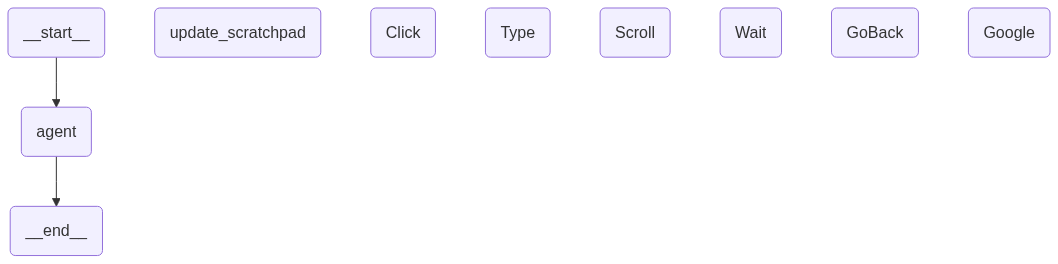

In [25]:
graph

In [26]:
from IPython import display
from playwright.async_api import async_playwright

browser = await async_playwright().start()
# We will set headless=False so we can watch the agent navigate the web.
browser = await browser.chromium.launch(headless=False, args=None)
page = await browser.new_page()
_ = await page.goto("https://duckduckgo.com/")


async def call_agent(question: str, page, max_steps: int = 150):
    event_stream = graph.astream(
        {
            "page": page,
            "input": question,
            "scratchpad": [],
        },
        {
            "recursion_limit": max_steps,
        },
    )
    final_answer = None
    steps = []
    async for event in event_stream:
        # We'll display an event stream here
        if "agent" not in event:
            continue
        pred = event["agent"].get("prediction") or {}
        action = pred.get("action")
        action_input = pred.get("args")
        display.clear_output(wait=False)
        steps.append(f"{len(steps) + 1}. {action}: {action_input}")
        print("\n".join(steps))
        display.display(display.Image(base64.b64decode(event["agent"]["img"])))
        if "ANSWER" in action:
            final_answer = action_input[0]
            break
    return final_answer

1. Click: ['1']
2. Type: ['1', 'JBS noticias de corrupção']
3. Click: ['36']
4. Click: ['27']
5. Click: ['2']
6. Scroll: ['WINDOW', 'down']
7. retry: Could not parse LLM Output: **Thought:** The current webpage contains news articles and some elements related to sports and shows. The goal is to check if there are any news articles related to corruption involving JBS.

**Action:** Click 158
8. Click: ['160']
9. Scroll: ['WINDOW', 'down']
10. Scroll: ['WINDOW', 'down']
11. Scroll: ['WINDOW', 'down']
12. Click: ['12']
13. retry: Could not parse LLM Output: **Thought:** The webpage contains information and news about JBS, specifically regarding corruption allegations. The next logical step would be to proceed or click a relevant link to gather more information.

**Action:** Click 1162
14. Click: ['12']


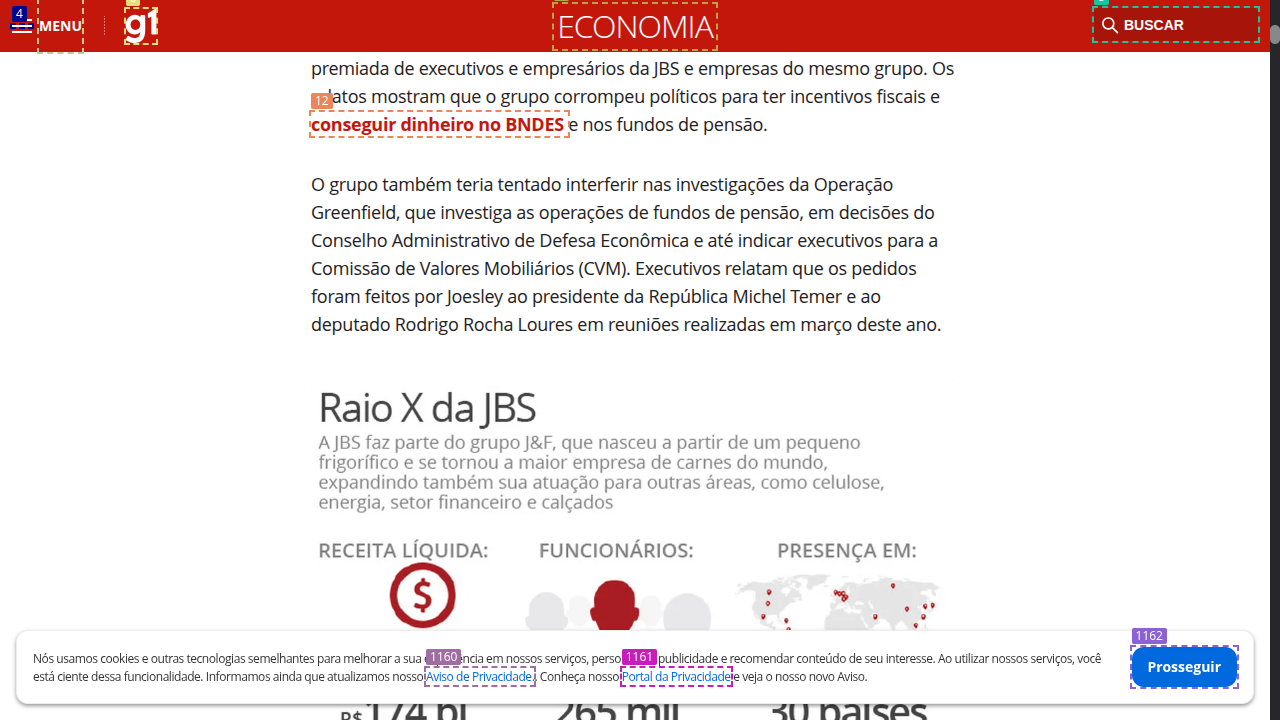

Running update_scratchpad
annotate
Running format_descriptions


CancelledError: 

In [27]:
res = await call_agent("Persquise se JBS tem noticias de corrupção", page)
print(f"Final response: {res}")

In [18]:
await browser.close()